# **Hold SNM Monte Carlo**

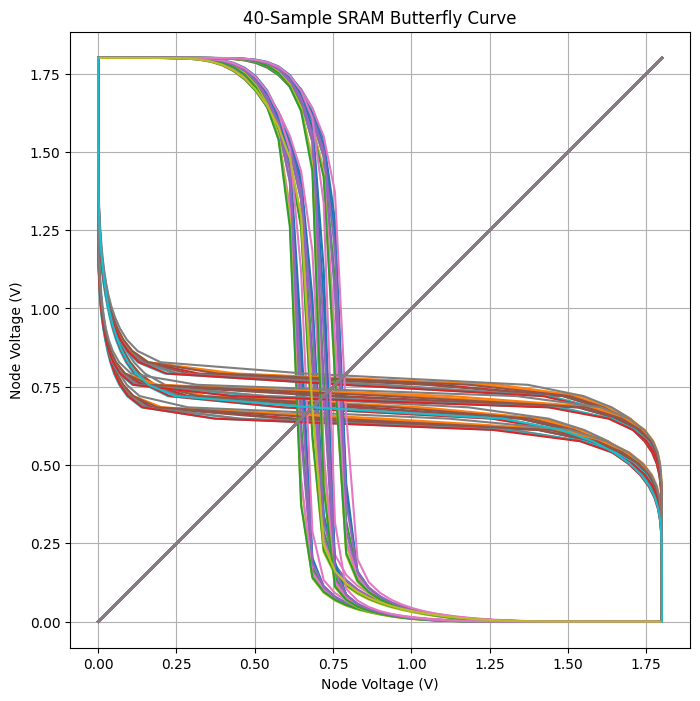

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("monte carlo.csv")

plt.figure(figsize=(8,8))

# Plot all Monte Carlo samples
for i in range(0, len(df.columns), 2):

    vin = df.iloc[:, i]
    vout = df.iloc[:, i+1]

    # First inverter
    plt.plot(vin, vout)

    # Mirrored inverter
    plt.plot(vout, vin)

plt.xlabel("Node Voltage (V)")
plt.ylabel("Node Voltage (V)")
plt.title("40-Sample SRAM Butterfly Curve")
plt.grid(True)
plt.axis('equal')

plt.show()

# **Read SNM Monte Carlo**

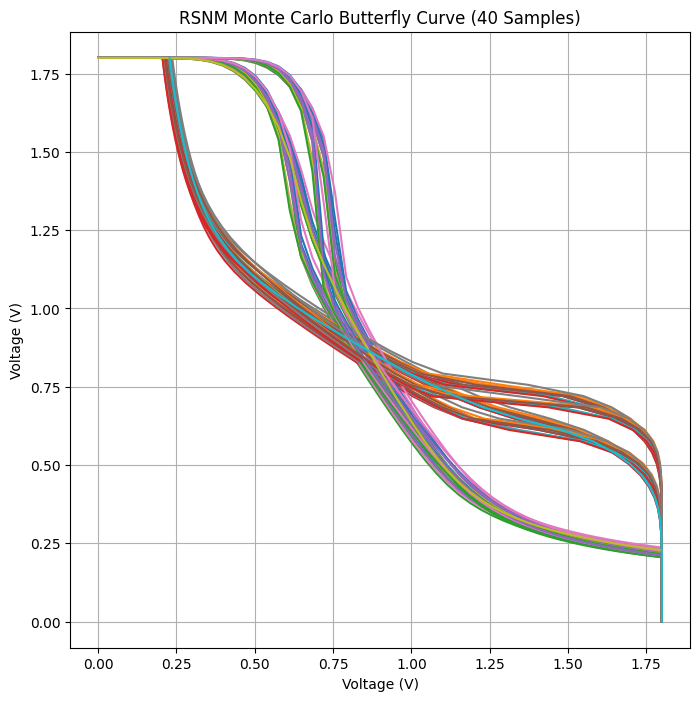

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load RSNM Monte Carlo data
df = pd.read_csv("RSNM_monte_carlo.csv")

plt.figure(figsize=(8,8))

for i in range(0, len(df.columns), 2):

    col_name = df.columns[i]

    # Use only Q curves
    if "/Q" in col_name:

        vin = pd.to_numeric(df.iloc[:, i], errors='coerce')
        vout = pd.to_numeric(df.iloc[:, i+1], errors='coerce')

        valid = ~(vin.isna() | vout.isna())

        vin = vin[valid]
        vout = vout[valid]

        # Original inverter
        plt.plot(vin, vout)

        # Mirrored inverter
        plt.plot(vout, vin)

plt.xlabel("Voltage (V)")
plt.ylabel("Voltage (V)")
plt.title("RSNM Monte Carlo Butterfly Curve (40 Samples)")
plt.grid(True)

# Important for proper butterfly shape
plt.xlim(0,1.8)
plt.ylim(0,1.8)
plt.axis('equal')

plt.show()

# **Write SNM Monte Carlo**

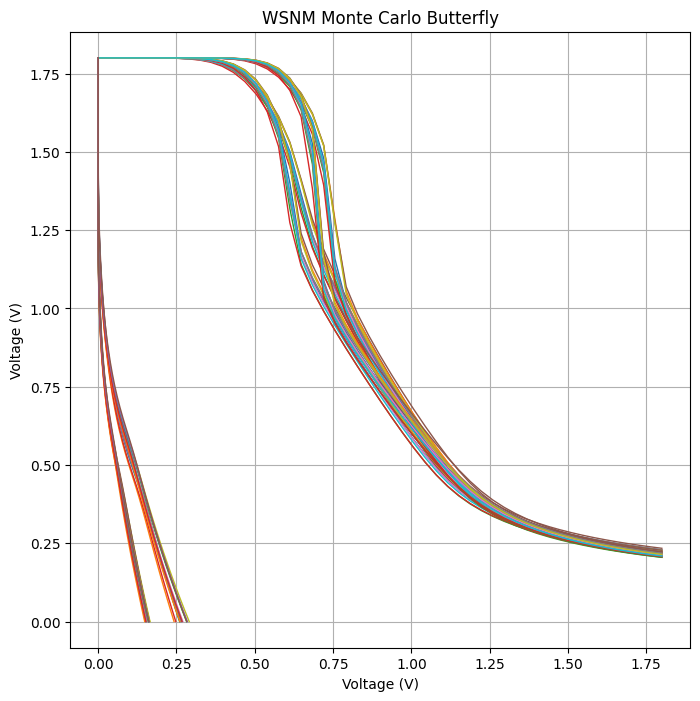

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("WSNM_monte_carlo.csv")

plt.figure(figsize=(8,8))

# ---------- QB : keep as VIN vs QB ----------
for col in df.columns:

    if col.startswith('/QB') and col.endswith('X'):

        vin = pd.to_numeric(df[col], errors='coerce')
        qb  = pd.to_numeric(df[col[:-1] + 'Y'], errors='coerce')

        valid = ~(vin.isna() | qb.isna())

        plt.plot(vin[valid], qb[valid], linewidth=1)


# ---------- Q : swap axes -> Q vs VIN ----------
for col in df.columns:

    if col.startswith('/Q') and not col.startswith('/QB') and col.endswith('X'):

        vin = pd.to_numeric(df[col], errors='coerce')
        q   = pd.to_numeric(df[col[:-1] + 'Y'], errors='coerce')

        valid = ~(vin.isna() | q.isna())

        plt.plot(q[valid], vin[valid], linewidth=1)


plt.xlabel('Voltage (V)')
plt.ylabel('Voltage (V)')
plt.title('WSNM Monte Carlo Butterfly')

plt.xlim(0,1.8)
plt.ylim(0,1.8)

plt.grid(True)
plt.axis('equal')

plt.show()